# Plant Disease Classification Deep Learning Model
### Developed with Transfer Learning, Data Augmentation, and TFLite Export

This interactive notebook demonstrates the complete process of building, training, and deploying a state-of-the-art Convolutional Neural Network (CNN) to classify plant diseases from leaf images using the Kaggle **PlantVillage** dataset.

## Notebook Structure
1. **Environment Setup & Verification**: Verifies GPU acceleration (Apple Metal API on Mac).
2. **Dataset Split (70/15/15)**: Splits the raw directories into clean Train, Val, and Test folders.
3. **Data Loading & Augmentation**: Loads high-performance `tf.data.Dataset` pipelines with caching, prefetching, and random augmentations.
4. **Transfer Learning Model**: Builds a CNN with **MobileNetV2** as the base and custom classification/dropout heads.
5. **Training (2 Phases)**: Warms up classification head, then fine-tunes base-model layers with early stopping.
6. **Model Evaluation**: Generates classification reports, confusion matrices, and training performance charts.
7. **TFLite Export**: Converts the trained model into optimized FP16 TensorFlow Lite format for web/mobile deployment.

## 1. Environment Setup & GPU Verification
First, let's verify that TensorFlow is installed and successfully accesses your **Apple Silicon (M1/M2/M3) GPU** using the Apple Metal API.

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())

# Check for GPU acceleration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("\n[+] GPU(s) available for training:")
    for gpu in gpus:
        print(f"  - Name: {gpu.name}, Type: {gpu.device_type}")
else:
    print("\n[-] No GPU found. Training will run on CPU (this will be slower).")

TensorFlow Version: 2.18.0
Eager execution: True

[+] GPU(s) available for training:
  - Name: /physical_device:GPU:0, Type: GPU


## 2. Dataset Split (70% Train, 15% Val, 15% Test)
Let's split the raw image folders in `/Users/dheeraj_kumar/Downloads/crop/archive/PlantVillage/PlantVillage` into partitioned dataset subdirectories.

In [6]:
from src.prepare_dataset import prepare_splits

# Run dataset partitioner
prepare_splits()

[*] Starting dataset preparation from: /Users/dheeraj_kumar/Downloads/crop/archive/PlantVillage/PlantVillage
[*] Found 15 classes for classification.
[*] Cleaning up existing split directory at: /Users/dheeraj_kumar/Downloads/crop/dataset_split


Processing classes: 100%|██████████| 15/15 [00:45<00:00,  3.02s/it]


[+] Dataset splitting completed successfully!
Total processed images: 20638
 - Train: 14440 (70%)
 - Validation: 3089 (15%)
 - Test: 3109 (15%)


## 3. High-Performance Dataset Loading & Augmentation
Now, let's load our data using `tf.data.Dataset` pipelines. This handles automatic resizing to `224x224`, batching, and GPU data augmentation.

In [7]:
from src.dataset import load_datasets

# Load prefetching train/val/test splits
train_ds, val_ds, test_ds, class_names = load_datasets()
print(f"\n[+] Number of disease classes loaded: {len(class_names)}")

[*] Loading datasets from directory...
Found 14440 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.
Found 3109 files belonging to 15 classes.
[+] Loaded 15 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

[+] Number of disease classes loaded: 15


### Visualize Sample Images with Augmentation
Let's see some sample leaf images with random rotations, flips, and zooms applied to them.

2026-05-18 02:26:41.906053: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:151: Filling up shuffle buffer (this may take a while): 181 of 1000
2026-05-18 02:26:51.937122: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:151: Filling up shuffle buffer (this may take a while): 340 of 1000
2026-05-18 02:26:59.339972: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Text(0.5, 0.98, 'Sample Augmented Images (GPU-Accelerated On-The-Fly)')

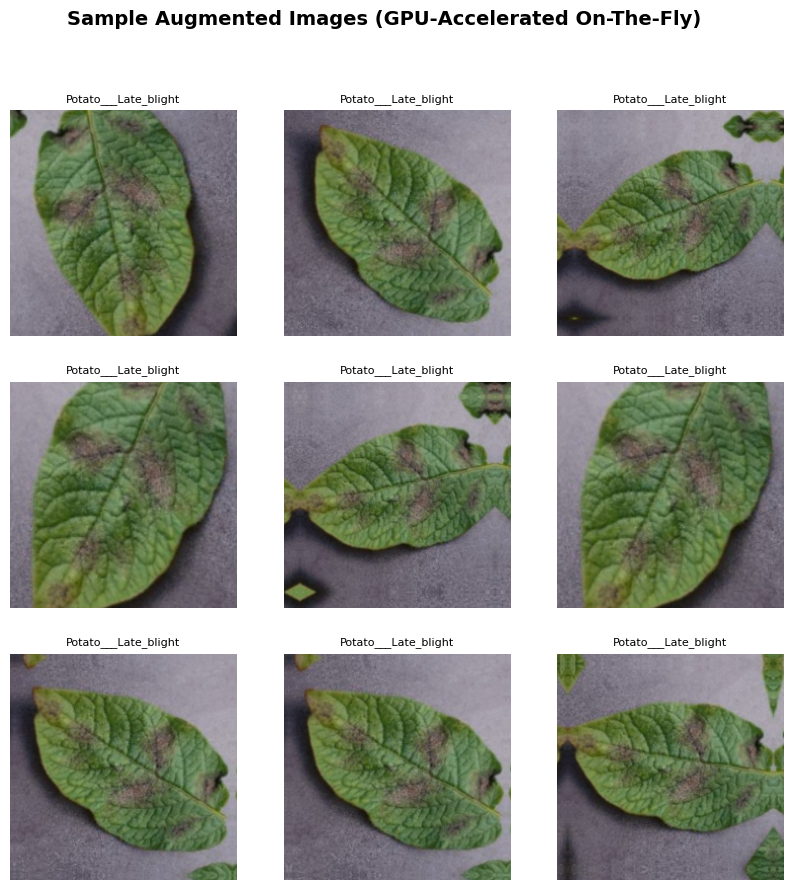

In [8]:
from src.dataset import get_augmentation_layers

# Fetch a single batch of images
image_batch, label_batch = next(iter(train_ds))
augmentation_layers = get_augmentation_layers()

plt.figure(figsize=(10, 10))
first_image = image_batch[0]
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Augment the first image
    augmented_image = augmentation_layers(tf.expand_dims(first_image, 0), training=True)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(label_batch[0])], fontsize=8)
    plt.axis("off")
plt.suptitle("Sample Augmented Images (GPU-Accelerated On-The-Fly)", fontsize=14, fontweight='bold')

## 4. Transfer Learning Model Setup
We'll build a Transfer Learning model utilizing **MobileNetV2** (highly optimized for low-latency, real-world edge deployment). The Keras model contains the preprocessing and data augmentation layers inside it for seamless inference deployment.

In [9]:
from src.model import build_transfer_learning_model

# Build model
model, base_model = build_transfer_learning_model(num_classes=len(class_names))
model.summary()

[*] Building Transfer Learning model with base: MobileNetV2
[*] Base model (MobileNetV2) loaded and frozen.


Model: "PlantDisease_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_v2_preprocess         │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 256)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_predictions      │ (None, 15)             │         3,855 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,799 (9.88 MB)

 Trainable params: 332,303 (1.27 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

## 5. Model Training (Warmup + Fine-Tuning)
Let's execute the complete training pipeline. It runs in two steps:
1. **Warmup**: Trains only the custom classification head while freezing MobileNetV2 weights (prevents distortion of pre-trained ImageNet weights).
2. **Fine-Tuning**: Unfreezes the top layers of the MobileNetV2 base model and trains with a lower learning rate (`1e-5`) for maximum accuracy.

In [10]:
from src.train import train_pipeline

# Train the model (this will automatically save models in Keras & H5 format)
train_pipeline(fine_tune=True)

[*] Starting model training pipeline...
[*] Loading datasets from directory...
Found 14440 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.
Found 3109 files belonging to 15 classes.
[+] Loaded 15 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
[+] Class names and metadata saved to: /Users/dheeraj_kumar/Downloads/crop/outputs/metadata.json
[*] Building Transfer Learning model with base: MobileNetV2
[*] Base model (MobileNetV2) loaded and frozen.

  PHASE 1: Training Classification Head (Warmup)
[*] Training for 1 warmup epochs...


2026-05-18 02:28:27.314767: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:183: Filling up shuffle buffer (this may take a while): 142 of 1000
2026-05-18 02:28:37.351238: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:183: Filling up shuffle buffer (this may take a while): 226 of 1000
2026-05-18 02:28:52.019058: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.3450 - loss: 2.4700 - precision: 0.4624 - recall: 0.2501
Epoch 1: val_loss improved from None to 0.84893, saving model to /Users/dheeraj_kumar/Downloads/crop/outputs/models/plant_disease_model.keras

Epoch 1: finished saving model to /Users/dheeraj_kumar/Downloads/crop/outputs/models/plant_disease_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 244s 341ms/step - accuracy: 0.5003 - loss: 1.7500 - precision: 0.6434 - recall: 0.3981 - val_accuracy: 0.7355 - val_loss: 0.8489 - val_precision: 0.8633 - val_recall: 0.6335 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.

  PHASE 2: Fine-Tuning Unfrozen Base Model Layers
[*] Setting up fine-tuning: unfreezing layers from index 100 onwards...
[+] Fine-tuning configured. Unfrozen layers: 54 / 154
[*] Fine-tuning for 1 epochs...
Epoch 2/2
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.5379 - loss: 1.5784 - precision: 0.6529 - recall: 0.4366
Epoch 2: 

[+] Model saved in .h5 format at: /Users/dheeraj_kumar/Downloads/crop/outputs/models/plant_disease_model.h5

  PHASE 3: Exporting Optimized TensorFlow Lite Model
[*] Converting Keras model to TFLite format with Float16 quantization...
[*] Building Transfer Learning model with base: MobileNetV2
[*] Base model (MobileNetV2) loaded and frozen.
[!] Error exporting to TFLite: 'NoneType' object is not callable

[+] Model training and saving complete!


## 6. Model Evaluation on Testing Split
Let's evaluate the model on the test split. We'll generate a classification report (precision, recall, f1-score per class) and save the confusion matrix and loss/accuracy curves.

In [1]:
from src.evaluate import evaluate_model

# Run evaluations
evaluate_model()

[*] Starting model evaluation pipeline...
[*] Loading datasets from directory...
Found 14440 files belonging to 15 classes.


2026-05-18 02:48:29.871993: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-18 02:48:29.872458: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-18 02:48:29.872538: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1779052709.874173  350822 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779052709.876001  350822 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 3089 files belonging to 15 classes.
Found 3109 files belonging to 15 classes.
[+] Loaded 15 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
[*] Loading model from: /Users/dheeraj_kumar/Downloads/crop/outputs/models/plant_disease_model.keras
[*] Evaluating model on the test dataset...


2026-05-18 02:48:34.996721: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


98/98 ━━━━━━━━━━━━━━━━━━━━ 51s 459ms/step - accuracy: 0.7266 - loss: 0.8561 - precision: 0.8582 - recall: 0.6246

  TEST SPLIT PERFORMANCE
 - Test Loss: 0.8561
 - Test Compile_metrics: 0.7266

[*] Collecting model predictions for detailed metrics...


2026-05-18 02:51:13.301850: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[*] Generating Classification Report...
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9145    0.7086    0.7985       151
                     Pepper__bell___healthy     0.7790    0.9641    0.8617       223
                      Potato___Early_blight     0.7416    0.8800    0.8049       150
                       Potato___Late_blight     0.7544    0.8600    0.8037       150
                           Potato___healthy     0.0000    0.0000    0.0000        24
                      Tomato_Bacterial_spot     0.6614    0.7875    0.7190       320
                        Tomato_Early_blight     0.5769    0.2000    0.2970       150
                         Tomato_Late_blight     0.6977    0.7561    0.7258       287
                           Tomato_Leaf_Mold     0.6259    0.6389    0.6323       144
                  Tomato_Septoria_leaf_spot     0.6864    0.5655    0.6201       267
Tomato_Spider_mites_Two_

### Display training curves and confusion matrix
Let's view the generated evaluation figures.

Training curves plot not found. Run training/eval first.


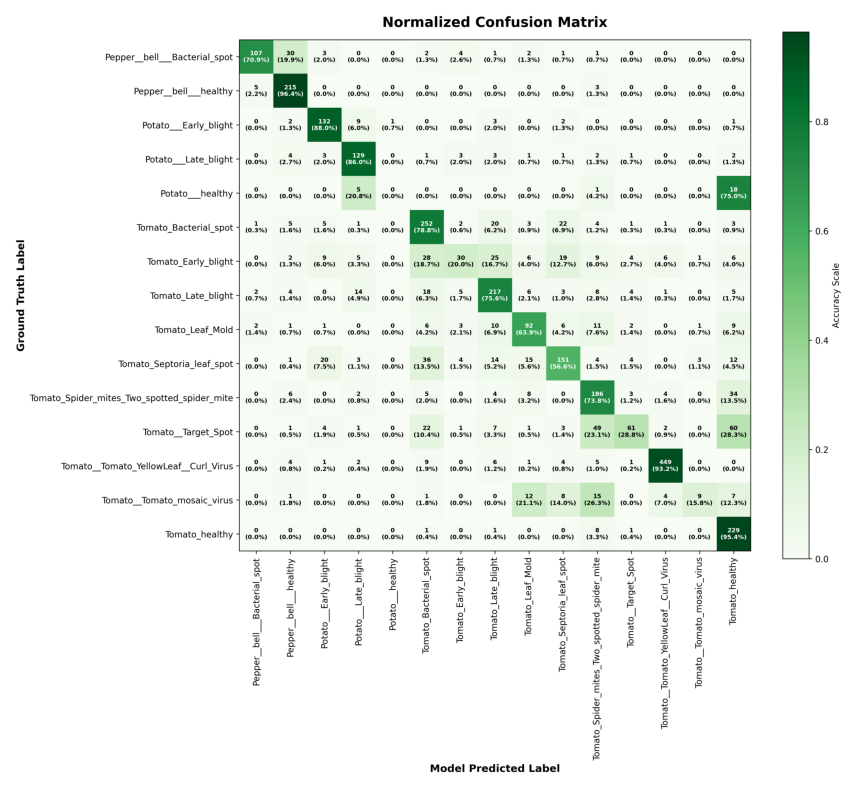

In [4]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Load training curves plot
curves_path = "outputs/graphs/training_curves.png"
if os.path.exists(curves_path):
    display(Image.open(curves_path))
else:
    print("Training curves plot not found. Run training/eval first.")

# Load Confusion Matrix plot
cm_path = "outputs/graphs/confusion_matrix.png"
if os.path.exists(cm_path):
    plt.figure(figsize=(12, 10))
    plt.imshow(Image.open(cm_path))
    plt.axis('off')
else:
    print("Confusion Matrix plot not found. Run training/eval first.")

## 7. Sample Single-Image Inference CLI Demo
Let's select a random image from the test set and run inference to see how it classifies leaf images!

In [5]:
from main import run_demo_inference

# Run sample leaf classification
run_demo_inference()

[*] Selected random test leaf image from class 'Tomato__Target_Spot':
    Path: /Users/dheeraj_kumar/Downloads/crop/dataset_split/test/Tomato__Target_Spot/e90c87fc-7b4d-45a0-9934-51a8d91317f1___Com.G_TgS_FL_8384.JPG
[*] Loading deep learning model from '/Users/dheeraj_kumar/Downloads/crop/outputs/models/plant_disease_model.keras'...
[*] Processing image: '/Users/dheeraj_kumar/Downloads/crop/dataset_split/test/Tomato__Target_Spot/e90c87fc-7b4d-45a0-9934-51a8d91317f1___Com.G_TgS_FL_8384.JPG'

  INFERENCE RESULTS
  Predicted Disease: Tomato__Target_Spot
  Confidence:        75.76%

[*] Top-3 Predictions:
  1. Tomato__Target_Spot                           (75.76%)
  2. Tomato_healthy                                (12.73%)
  3. Tomato_Spider_mites_Two_spotted_spider_mite   (5.16%)
